In [1]:
import json
import numpy as np
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
# load patient data
with open('mri_scans.json', 'r') as f:
    mri_scans = json.load(f)
patient_data = pd.read_csv('patient_data.csv')

In [3]:
print(patient_data.describe())

       Unnamed: 0  RNASeqCluster  MethylationCluster  miRNACluster  \
count  110.000000      92.000000          109.000000    110.000000   
mean    54.500000       2.445652            3.678899      1.900000   
std     31.898276       1.180092            1.169684      0.789263   
min      0.000000       1.000000            1.000000      1.000000   
25%     27.250000       1.000000            3.000000      1.000000   
50%     54.500000       2.000000            4.000000      2.000000   
75%     81.750000       4.000000            5.000000      2.000000   
max    109.000000       4.000000            5.000000      4.000000   

        CNCluster  RPPACluster  OncosignCluster  COCCluster  \
count  108.000000    98.000000       105.000000  110.000000   
mean     1.722222     2.367347         1.895238    1.763636   
std      0.862872     1.125045         0.663960    0.855927   
min      1.000000     1.000000         1.000000    1.000000   
25%      1.000000     1.000000         1.000000    1.0

In [4]:
#print(patient_data[patient_data['histological_type'].isna()])
print(patient_data.iloc[109])
#plt.pie(patient_data['histological_type'])

Unnamed: 0                            109
Patient                      TCGA_HT_A61B
RNASeqCluster                         NaN
MethylationCluster                    5.0
miRNACluster                            2
CNCluster                             1.0
RPPACluster                           NaN
OncosignCluster                       2.0
COCCluster                              1
histological_type                     NaN
neoplasm_histologic_grade             NaN
tumor_tissue_site                     NaN
laterality                            NaN
tumor_location                        NaN
gender                                NaN
age_at_initial_pathologic             NaN
race                                  NaN
ethnicity                             NaN
death01                               NaN
Name: 109, dtype: object


['RNASeqCluster', 'MethylationCluster', 'miRNACluster', 'CNCluster', 'RPPACluster', 'OncosignCluster', 'COCCluster']


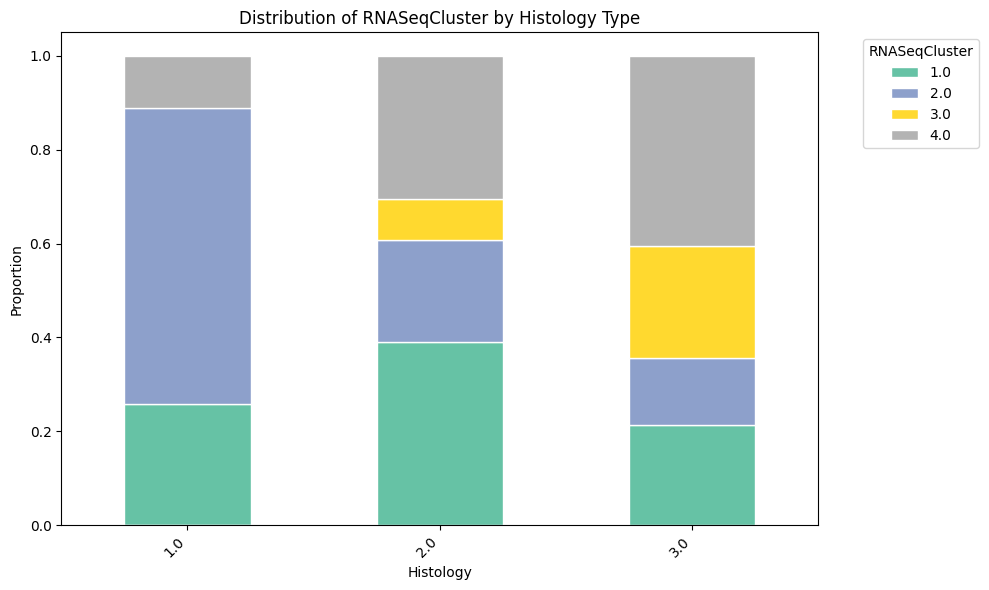

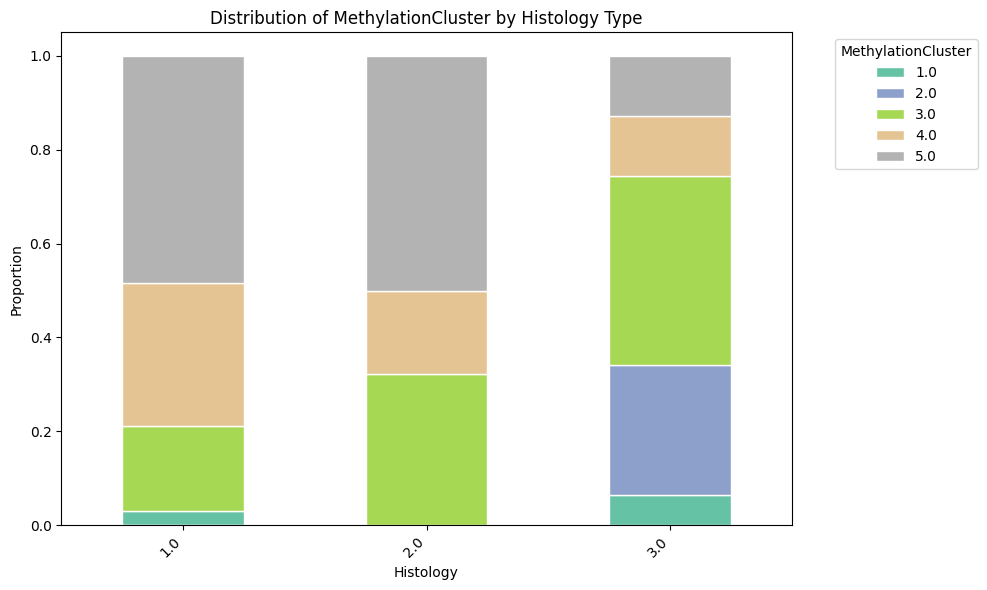

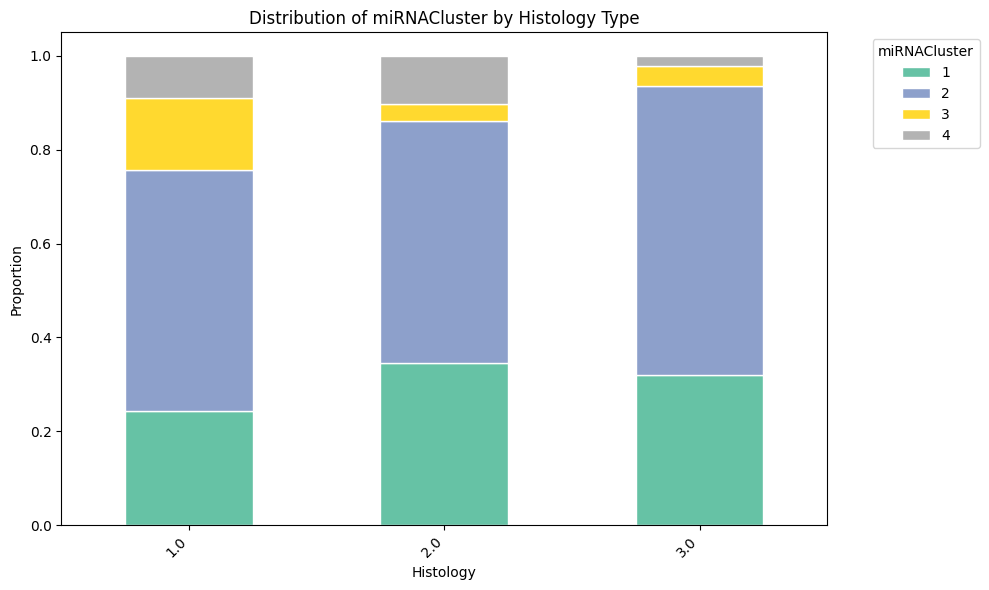

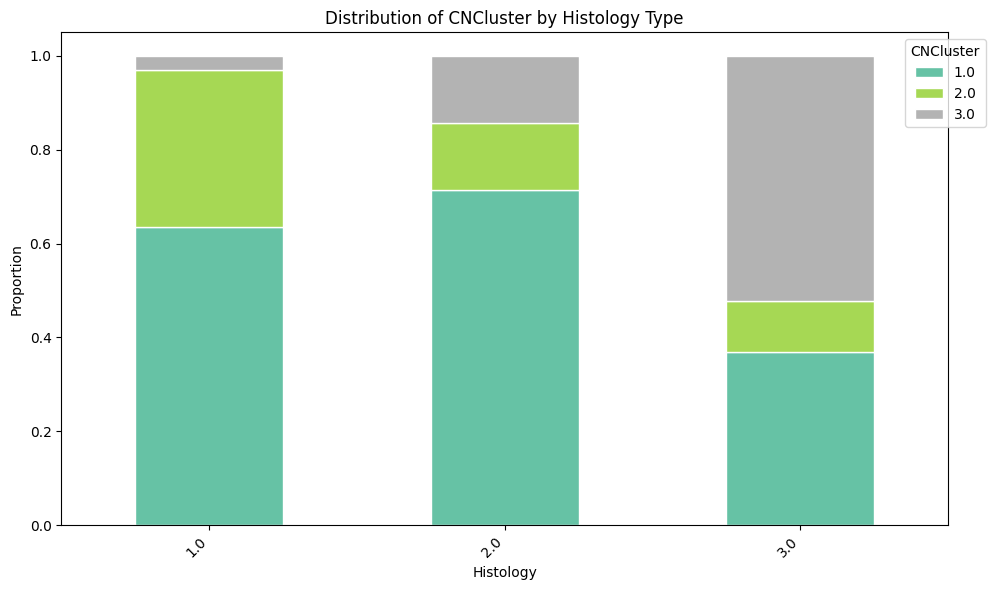

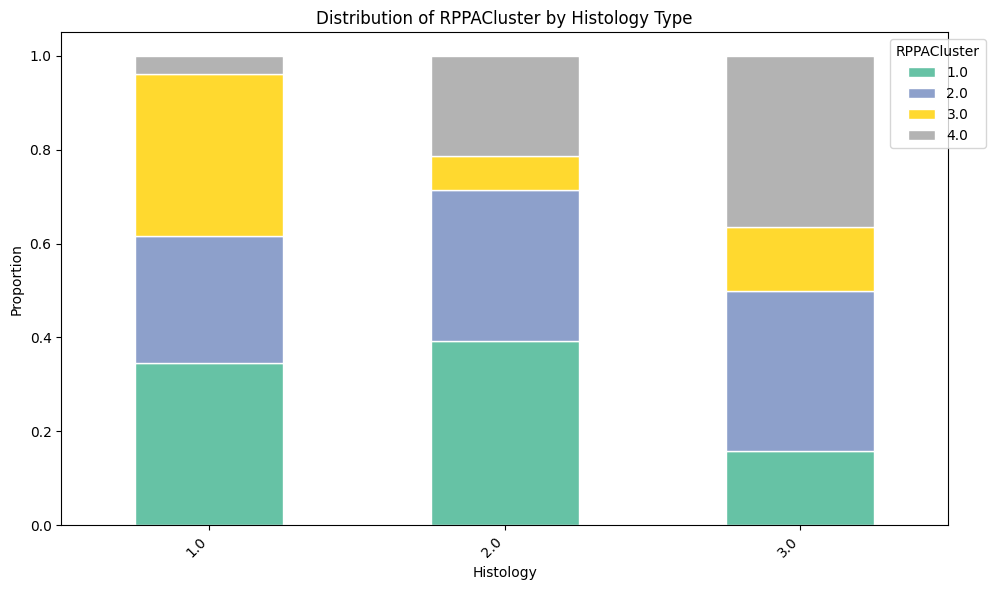

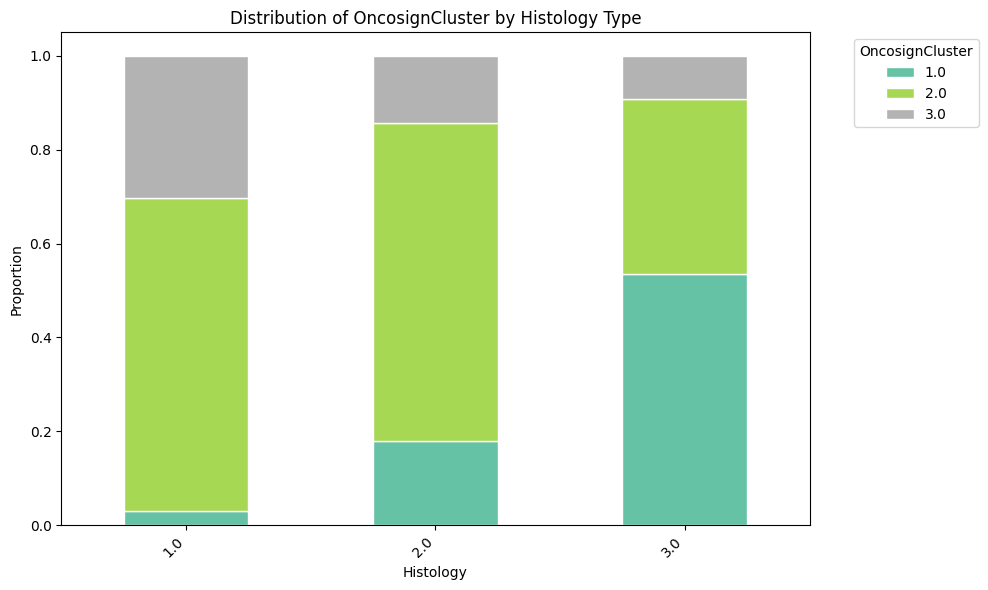

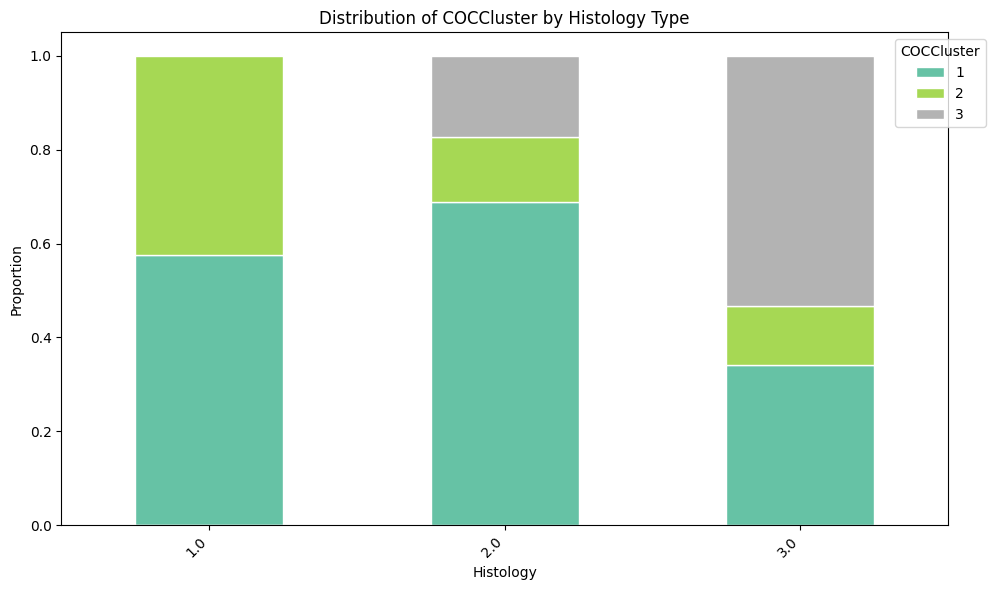

In [5]:
rna_exps = [col for col in patient_data.columns if "Cluster" in col]
print(rna_exps)

# display the proportions of RNA expression for each category of histology
for col in rna_exps:
    crosstab = pd.crosstab(
        patient_data["histological_type"], 
        patient_data[col],
        normalize='index'
    )
    
    ax = crosstab.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    colormap='Set2',
    edgecolor='white'
    )
    
    plt.title(f'Distribution of {col} by Histology Type')
    plt.xlabel('Histology')
    plt.ylabel('Proportion')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title=f'{col}', bbox_to_anchor=(1.05, 1))
    plt.tight_layout()
    plt.show()

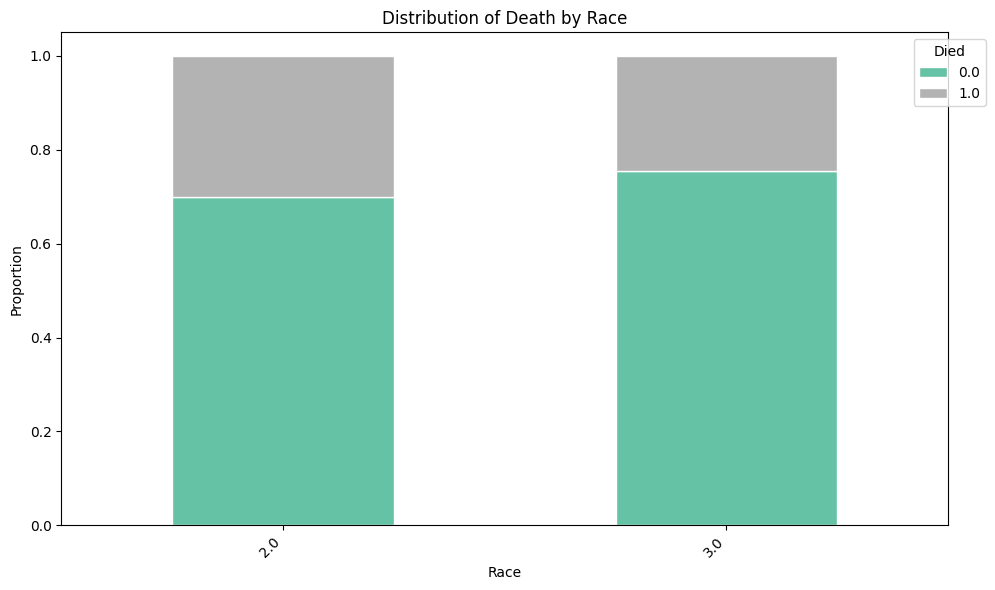

In [6]:
crosstab = pd.crosstab(
    patient_data["race"], 
    patient_data['death01'],
    normalize='index'
)

ax = crosstab.plot(
kind='bar',
stacked=True,
figsize=(10, 6),
colormap='Set2',
edgecolor='white'
)

plt.title(f'Distribution of Death by Race')
plt.xlabel('Race')
plt.ylabel('Proportion')
plt.xticks(rotation=45, ha='right')
plt.legend(title=f'Died', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

In [7]:

missing_counts = patient_data.isna().sum()    # counts all missing values
na_cols = []

for col, count in missing_counts.items():
    status = "no"
    end = ""
    if count != 0:
        indices = list(np.where(patient_data[col].isna()))
        if count == 1 and indices[0] == 109:   # omit patient 109, will be deleted
            continue
        status = count
        na_cols.append(col)
        end = f"in rows {indices}"
    start = f"Column '{col}' has {status} missing values"
    print(start, end)

Column 'Unnamed: 0' has no missing values 
Column 'Patient' has no missing values 
Column 'RNASeqCluster' has 18 missing values in rows [array([  3,   7,  12,  23,  31,  37,  40,  45,  56,  63,  69,  75,  80,
        83,  97, 107, 108, 109])]
Column 'MethylationCluster' has 1 missing values in rows [array([80])]
Column 'miRNACluster' has no missing values 
Column 'CNCluster' has 2 missing values in rows [array([ 70, 108])]
Column 'RPPACluster' has 12 missing values in rows [array([  0,   5,  10,  13,  40,  68,  75, 105, 106, 107, 108, 109])]
Column 'OncosignCluster' has 5 missing values in rows [array([ 35,  62,  63,  70, 108])]
Column 'COCCluster' has no missing values 
Column 'race' has 2 missing values in rows [array([ 10, 109])]
Column 'ethnicity' has 8 missing values in rows [array([  1,   2,   3,   4,   5,  10,  15, 109])]
